# Data Audit & Viability Check
**Objective:** Determine if the dataset supports Causal Dynamic Pricing.
**Inputs:** `calendar.csv`, `listings.csv`

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent dir to path to import pricing_engine
sys.path.append(os.path.abspath('..'))

from pricing_engine.audit import MarketAuditor, AuditThresholds

## 1. Load Data
*Replace paths with your actual file locations*

In [2]:
from pathlib import Path



try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

# SCRIPT_DIR is the 'notebooks' folder.
# SCRIPT_DIR.parent is the 'Dynamic Pricing Engine' folder.
PROJECT_ROOT = SCRIPT_DIR.parent

# Now build the path from the project root
CALENDAR_PATH = PROJECT_ROOT / 'data' / 'calendar.csv'
LISTINGS_PATH = PROJECT_ROOT / 'data' / 'listings.csv'



In [3]:
# --- REPAIR & DIAGNOSIS CELL ---
import pandas as pd
import numpy as np

# 1. Reload Raw Data (Force all columns to string to see raw format)
print("Reloading raw data...")
df_cal_raw = pd.read_csv(CALENDAR_PATH, dtype=str)

print("\n--- RAW PRICE SAMPLES (Check Format) ---")
print(df_cal_raw['price'].dropna().head(10).tolist())

# 2. Universal Price Cleaner Function
def clean_price_robust(price_series):
    # Convert to string
    s = price_series.astype(str)
    
    # Remove Currency Symbols ($, €) and spaces
    s = s.str.replace(r'[^\d,.-]', '', regex=True)
    
    # DETECT FORMAT: If we see a comma, is it a decimal or thousand separator?
    # Heuristic: If comma is near the end (2 digits after), replace with dot.
    # Otherwise remove it.
    
    # Case A: Standard US ($1,200.00) -> Remove comma
    # Case B: Euro (1.200,00) -> Swap dot/comma is complex, 
    # Let's assume InsideAirbnb standard: $ and , are noise. 
    # But if Bordeaux uses , for decimals, we must handle it.
    
    # Check the first non-null value to decide strategy
    sample = s.iloc[0] if len(s) > 0 else ""
    if "," in sample and "." not in sample:
        # Likely French format (100,00) -> Replace , with .
        print(f"Detected potential Euro/French format (e.g. {sample}). Swapping ',' to '.'")
        s = s.str.replace(',', '.')
    else:
        # Likely US format ($1,200.00) -> Remove comma
        s = s.str.replace(',', '')
        
    return pd.to_numeric(s, errors='coerce')

# 3. Apply Fix
print("\nApplying Fix...")
df_cal_raw['price_clean'] = clean_price_robust(df_cal_raw['price'])

# 4. Verify Success
print("\n--- CLEANED PRICE STATS ---")
print(df_cal_raw[['price', 'price_clean']].head(10))
print(f"\nValid Prices Count: {df_cal_raw['price_clean'].count()} / {len(df_cal_raw)}")
print(f"Mean Price: {df_cal_raw['price_clean'].mean():.2f}")

# 5. Overwrite the main dataframe for the Auditor
df_cal = df_cal_raw.copy()
df_cal['price'] = df_cal['price_clean']
# Drop the temp column and missing values
df_cal['price_missing'] = df_cal['price'].isna()
df_list = pd.read_csv(LISTINGS_PATH)

Reloading raw data...

--- RAW PRICE SAMPLES (Check Format) ---
['$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00']

Applying Fix...

--- CLEANED PRICE STATS ---
    price  price_clean
0  $85.00         85.0
1  $85.00         85.0
2     NaN          NaN
3     NaN          NaN
4     NaN          NaN
5     NaN          NaN
6     NaN          NaN
7     NaN          NaN
8     NaN          NaN
9  $85.00         85.0

Valid Prices Count: 934542 / 1393570
Mean Price: 137.94


## 2. Initialize Auditor & Clean Data

In [4]:
auditor = MarketAuditor(AuditThresholds(
    min_price_std=5.0,        # A listing must vary price by at least $5 std dev
    min_bookings=10,          # Less than 10 bookings = Cold Start
    min_variance_coverage=0.3 # 30% of market must be active
))

df_clean = auditor.clean_and_prep(df_cal, df_list)
df_clean.head()

2025-12-31 22:02:07,611 - INFO - Cleaning and merging data...
2025-12-31 22:02:08,560 - INFO - Data Prep Complete. Rows: 1393570


,listing_id,date,available,price,price_clean,price_missing,is_booked,dow,id,neighbourhood_cleansed
0,241032,2016-01-04,t,85.0,85.0,False,0,0,241032,West Queen Anne
1,241032,2016-01-05,t,85.0,85.0,False,0,1,241032,West Queen Anne
2,241032,2016-01-06,f,NaN,NaN,True,1,2,241032,West Queen Anne
3,241032,2016-01-07,f,NaN,NaN,True,1,3,241032,West Queen Anne
4,241032,2016-01-08,f,NaN,NaN,True,1,4,241032,West Queen Anne


## 3. Identifiability Check (Price Variance)
*Do we have enough price movement to learn elasticity?*

2025-12-31 22:02:57,669 - INFO - Checking Identifiability (Price Variance)...


--- Identifiability Report ---
Percent listings with price variation: 42.43%
Decision: PASS


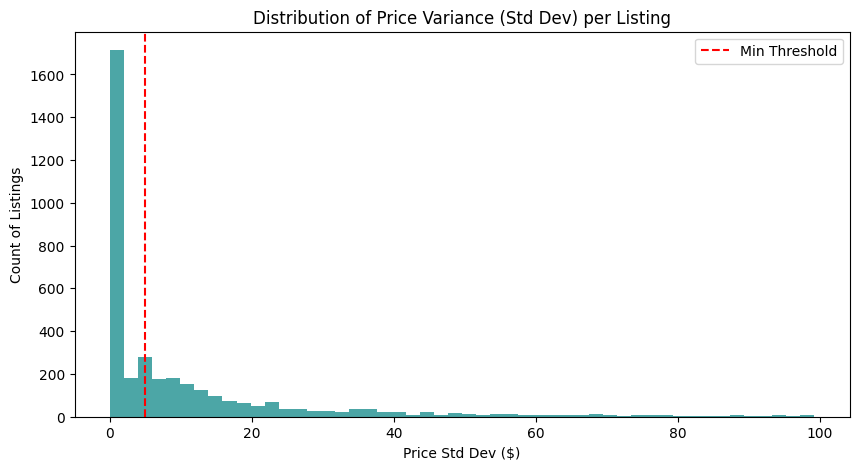

In [8]:
id_metrics = auditor.check_identifiability(df_clean)
print("--- Identifiability Report ---")
print(f"Percent listings with price variation: {id_metrics['pct_identifiable']:.2%}")
print(f"Decision: {id_metrics['status']}")

# VISUALIZATION: Histogram of Price Std Dev
price_std = (
    df_clean.dropna(subset=['price'])
      .groupby('listing_id')['price']
      .std()
)

plt.figure(figsize=(10, 5))
plt.hist(price_std[price_std < 100], bins=50, color='teal', alpha=0.7)
plt.axvline(auditor.thresh.min_price_std, color='red', linestyle='--', label='Min Threshold')
plt.title("Distribution of Price Variance (Std Dev) per Listing")
plt.xlabel("Price Std Dev ($)")
plt.ylabel("Count of Listings")
plt.legend()
plt.show()

## 4. Sparsity Check (Cold Start)
*Is the data too sparse for individual models?*

In [9]:
sparsity_metrics = auditor.check_sparsity(df_clean)
print("--- Sparsity Report ---")
print(f"Percent Cold Start (<{auditor.thresh.min_bookings} bookings): {sparsity_metrics['pct_cold_start']:.2%}")
print(f"Percent Zero Bookings: {sparsity_metrics['pct_zero_bookings']:.2%}")
print(f"Architecture Recommendation: {sparsity_metrics['recommendation']}")

2025-12-31 22:03:02,568 - INFO - Checking Sparsity (Cold Start)...


--- Sparsity Report ---
Percent Cold Start (<10 bookings): 29.78%
Percent Zero Bookings: 17.76%
Architecture Recommendation: INDEPENDENT_MODELS


## 5. Confounding Check (Simpson's Paradox)
*Does Raw Correlation mislead us compared to Stratified Correlation?*

In [10]:
def demand_slope_by_price(df, group_col=None):
    tmp = df.copy()
    tmp = tmp[tmp['price'] > 0]
    tmp['price_bin'] = pd.qcut(tmp['price'], q=10, duplicates='drop')

    if group_col:
        slopes = []
        for _, g in tmp.groupby(group_col):
            if g['price_bin'].nunique() < 5:
                continue
            rates = g.groupby('price_bin')['is_booked'].mean()
            slopes.append(np.corrcoef(range(len(rates)), rates)[0, 1])
        return np.nanmean(slopes)
    else:
        rates = tmp.groupby('price_bin')['is_booked'].mean()
        return np.corrcoef(range(len(rates)), rates)[0, 1]


In [11]:
raw_slope = demand_slope_by_price(df_clean)
strat_slope = demand_slope_by_price(df_clean, group_col='dow')

print("--- Confounding Report (Slope-Based) ---")
print(f"Raw Price→Demand Slope: {raw_slope:.3f}")
print(f"Stratified (DoW) Slope: {strat_slope:.3f}")
print(f"Confounding Detected: {raw_slope >= 0 and strat_slope < 0}")


C:\Users\99sma\AppData\Local\Temp\ipykernel_17544\4085330101.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = tmp.groupby('price_bin')['is_booked'].mean()
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


--- Confounding Report (Slope-Based) ---
Raw Price→Demand Slope: nan
Stratified (DoW) Slope: nan
Confounding Detected: False


C:\Users\99sma\AppData\Local\Temp\ipykernel_17544\4085330101.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = g.groupby('price_bin')['is_booked'].mean()
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\99sma\AppData\Local\Temp\ipykernel_17544\4085330101.py:13: RuntimeWarning: Mean of empty slice
  return np.nanmean(slopes)


2025-12-31 22:03:20,626 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-31 22:03:21,539 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


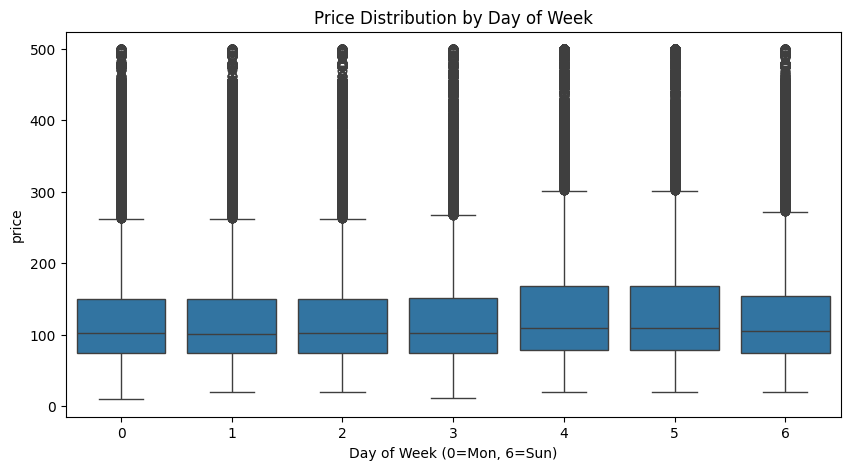

In [12]:
# VISUALIZATION: Price vs Booking Rate by Day of Week
# We expect higher prices on weekends (5,6) but potentially higher booking rates too (confounding)
plt.figure(figsize=(10, 5))
sns.boxplot(x='dow', y='price', data=df_clean[df_clean['price'] < 500])
plt.title("Price Distribution by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.show()

In [13]:
if id_metrics['status'] == 'PASS':
    print("✅ AUDIT PASSED: Proceed to Module 01 (Causal Identification)")
else:
    print("❌ AUDIT FAILED: Data lacks sufficient price variation.")

✅ AUDIT PASSED: Proceed to Module 01 (Causal Identification)


In [15]:
# --- RUN FINAL AUDIT ---
# Ensure we have the auditor initialized
auditor = MarketAuditor(AuditThresholds(
    min_price_std=5.0,         # Listing must vary price by > $5
    min_bookings=10,           # < 10 bookings = Cold Start
    min_variance_coverage=0.20 # at least 20% of listings must vary price
))

# 1. Prepare the final dataframe (Merge cleaned calendar with listings)
# We need 'listing_id', 'price', 'is_booked', 'neighbourhood_group_cleansed'
listings_sub = df_list[['id', 'neighbourhood_group_cleansed']].rename(columns={'id': 'listing_id'})
df_final = df_cal.merge(listings_sub, on='listing_id', how='inner')

print(f"Final Audit Dataset: {len(df_final)} rows")

# 2. Execute Checks
id_metrics = auditor.check_identifiability(df_final)
sparsity_metrics = auditor.check_sparsity(df_final)


print("\n====== MODULE 00: FINAL REPORT ======")
print(f"1. Identifiability (Price Variance): {id_metrics['pct_identifiable']:.2%} of listings")
print(f"   -> Threshold: >{auditor.thresh.min_variance_coverage:.0%}")
print(f"   -> Status: {id_metrics['status']}")

print(f"\n2. Sparsity (Cold Start): {sparsity_metrics['pct_cold_start']:.2%} of listings are sparse")
print(f"   -> Recommendation: {sparsity_metrics['recommendation']}")



2025-12-31 22:03:42,031 - INFO - Checking Identifiability (Price Variance)...
2025-12-31 22:03:42,077 - INFO - Checking Sparsity (Cold Start)...


Final Audit Dataset: 1393570 rows

====== MODULE 00: FINAL REPORT ======
1. Identifiability (Price Variance): 42.43% of listings
   -> Threshold: >20%
   -> Status: PASS

2. Sparsity (Cold Start): 29.78% of listings are sparse
   -> Recommendation: INDEPENDENT_MODELS


In [16]:
if (
    id_metrics['pct_identifiable'] >= auditor.thresh.min_variance_coverage
    and sparsity_metrics['pct_zero_bookings'] < 0.8
):
    print("🟢 GO: Market supports causal dynamic pricing.")
else:
    print("🔴 NO-GO: Data unsuitable for safe pricing.")


🟢 GO: Market supports causal dynamic pricing.


In [17]:
availability_rate = (
    df_clean.groupby('listing_id')['available']
    .apply(lambda x: (x == 't').mean())
)

print("Median availability:", availability_rate.median())


Median availability: 0.8438356164383561


In [18]:
price_change_rate = (
    df_clean.dropna(subset=['price'])
    .groupby('listing_id')['price']
    .apply(lambda x: (x.diff() != 0).mean())
)

price_change_rate.describe()


count    3723.000000
mean        0.147176
std         0.191218
min         0.002740
25%         0.004132
50%         0.030120
75%         0.287671
max         1.000000
Name: price, dtype: float64